# Notebook 2 — Detección de anomalías y análisis de series de tiempo

## Contexto

Usando el **Boletín Epidemiológico DGE 2016–2026**, este notebook analiza el comportamiento temporal del sarampión y otras enfermedades exantemáticas en las tres ciudades sede del **FIFA World Cup 2026** (CDMX, Guadalajara, Monterrey).

### Objetivos
1. Detectar semanas anómalas en la serie de sarampión usando métodos estadísticos
2. Modelar el patrón estacional de las enfermedades como baseline
3. Proyectar el riesgo durante las semanas del Mundial (sem 23–27, jun–jul 2026)
4. Identificar qué sede tiene mayor exposición activa al momento del torneo

### Métodos de detección de anomalías
- **Z-Score** — desviaciones estándar respecto a la media histórica
- **IQR (Rango Intercuartílico)** — detección robusta a outliers
- **Media Móvil + Bandas de Control** — visualización de tendencia vs umbral


---
## 0. Imports y configuración

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from scipy.signal import savgol_filter

pd.set_option('display.float_format', '{:.2f}'.format)
sns.set_theme(style='whitegrid', palette='muted')

DATA_RAW       = 'content/data/raw/'
DATA_PROCESSED = 'content/data/processed/'
OUTPUT_FIGURES = 'content/reports/figures/'

for path in [DATA_RAW, DATA_PROCESSED, OUTPUT_FIGURES]:
    os.makedirs(path, exist_ok=True)

# Colores y constantes del proyecto
CIUDAD_COLORS = {'CDMX': '#4e8ec4', 'Guadalajara': '#d4a200', 'Monterrey': '#55a855'}
SEDES_MAP     = {
    'Ciudad de México' : 'CDMX',
    'Jalisco'          : 'Guadalajara',
    'Nuevo León'       : 'Monterrey',
}
ENFERMEDADES = ['Sarampion', 'Varicela', 'Escarlatina', 'Erisipela', 'Rubeola']

# Semanas del Mundial en México (jun-jul 2026)
MUNDIAL_START = 23   # sem 23 = 2026-06-08
MUNDIAL_END   = 27   # sem 27 = 2026-07-06
PARTIDOS_MEXICO = {
    23: {'CDMX': 'MEX vs RSA', 'Guadalajara': 'KOR vs EUR'},
    24: {'Monterrey': 'UKR vs TUN'},
    25: {'CDMX': 'UZB vs COL', 'Guadalajara': 'MEX vs KOR'},
    26: {'Monterrey': 'TUN vs JPN', 'CDMX': 'EUR vs MEX', 'Monterrey': 'RSA vs KOR'},
    27: {'CDMX': '16vos Final'},
}

print("✅ Imports y configuración OK")


✅ Imports y configuración OK


---
## 1. Carga y preparación de datos

In [ ]:
df_raw = pd.read_csv(DATA_RAW + 'boletin_epidemiologico_2016_2026.csv',
                     parse_dates=['fecha_inicio'])

print(f"Shape: {df_raw.shape}")
print(f"Años: {sorted(df_raw['anio'].unique())}")
print(f"Enfermedades: {sorted(df_raw['enfermedad'].unique())}")
df_raw.head(3)


Shape: (145268, 22)
Años: [np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025), np.int64(2026)]
Enfermedades: ['Erisipela', 'Escarlatina', 'Rubeola', 'Sarampion']


/tmp/ipykernel_10689/3338666171.py:1: DtypeWarning: Columns (19) have mixed types. Specify dtype option on import or set low_memory=False.
  df_raw = pd.read_csv(DATA_RAW + 'boletin_epidemiologico_2016_2026.csv',


,anio,semana,entidad_federativa,enfermedad,sexo,cie10,casos_semana,casos_acumulado,casos_acum_anterior,fuente,...,casos_ambos_sexos,casos_sem_total,casos_ant_total,tasa_crecimiento,incr_semanal,semana_sin,semana_cos,es_brote,casos_nuevos,casos_nuevos_total
0,2016,1,Aguascalientes,Erisipela,H,A46,0,0,1,boletin_pdf,...,2,0.00,2.00,1.00,0.00,0.12,0.99,False,0.00,0.00
1,2016,2,Aguascalientes,Erisipela,H,A46,0,0,0,boletin_pdf,...,0,0.00,0.00,NaN,0.00,0.24,0.97,False,0.00,0.00
2,2016,3,Aguascalientes,Erisipela,H,A46,0,0,0,boletin_pdf,...,0,0.00,0.00,NaN,0.00,0.35,0.94,False,0.00,0.00


In [ ]:
# Consolidar H+M en un solo registro por semana/entidad/enfermedad
# (usamos casos_semana que ya viene correcto del ETL)
df = (
    df_raw
    .groupby(['anio','semana','fecha_inicio','entidad_federativa','enfermedad','fuente'])
    ['casos_semana']
    .sum()
    .reset_index()
)

# Agregar ciudad sede
df['ciudad_sede'] = df['entidad_federativa'].map(SEDES_MAP)

# Filtrar solo sedes del Mundial
df_sedes = df[df['ciudad_sede'].notna()].copy()

print(f"Registros totales      : {len(df):,}")
print(f"Registros sedes        : {len(df_sedes):,}")
print(f"\nCasos por enfermedad en sedes:")
print(df_sedes.groupby('enfermedad')['casos_semana'].sum()
      .sort_values(ascending=False).to_string())


Registros totales      : 74,411
Registros sedes        : 7,139

Casos por enfermedad en sedes:
enfermedad
Erisipela      38112
Escarlatina    10155
Sarampion       2775
Rubeola            0


---
## 2. Series de tiempo por sede y enfermedad

Visualizamos la evolución semanal de cada enfermedad en las tres sedes,
marcando el período del Mundial 2026.


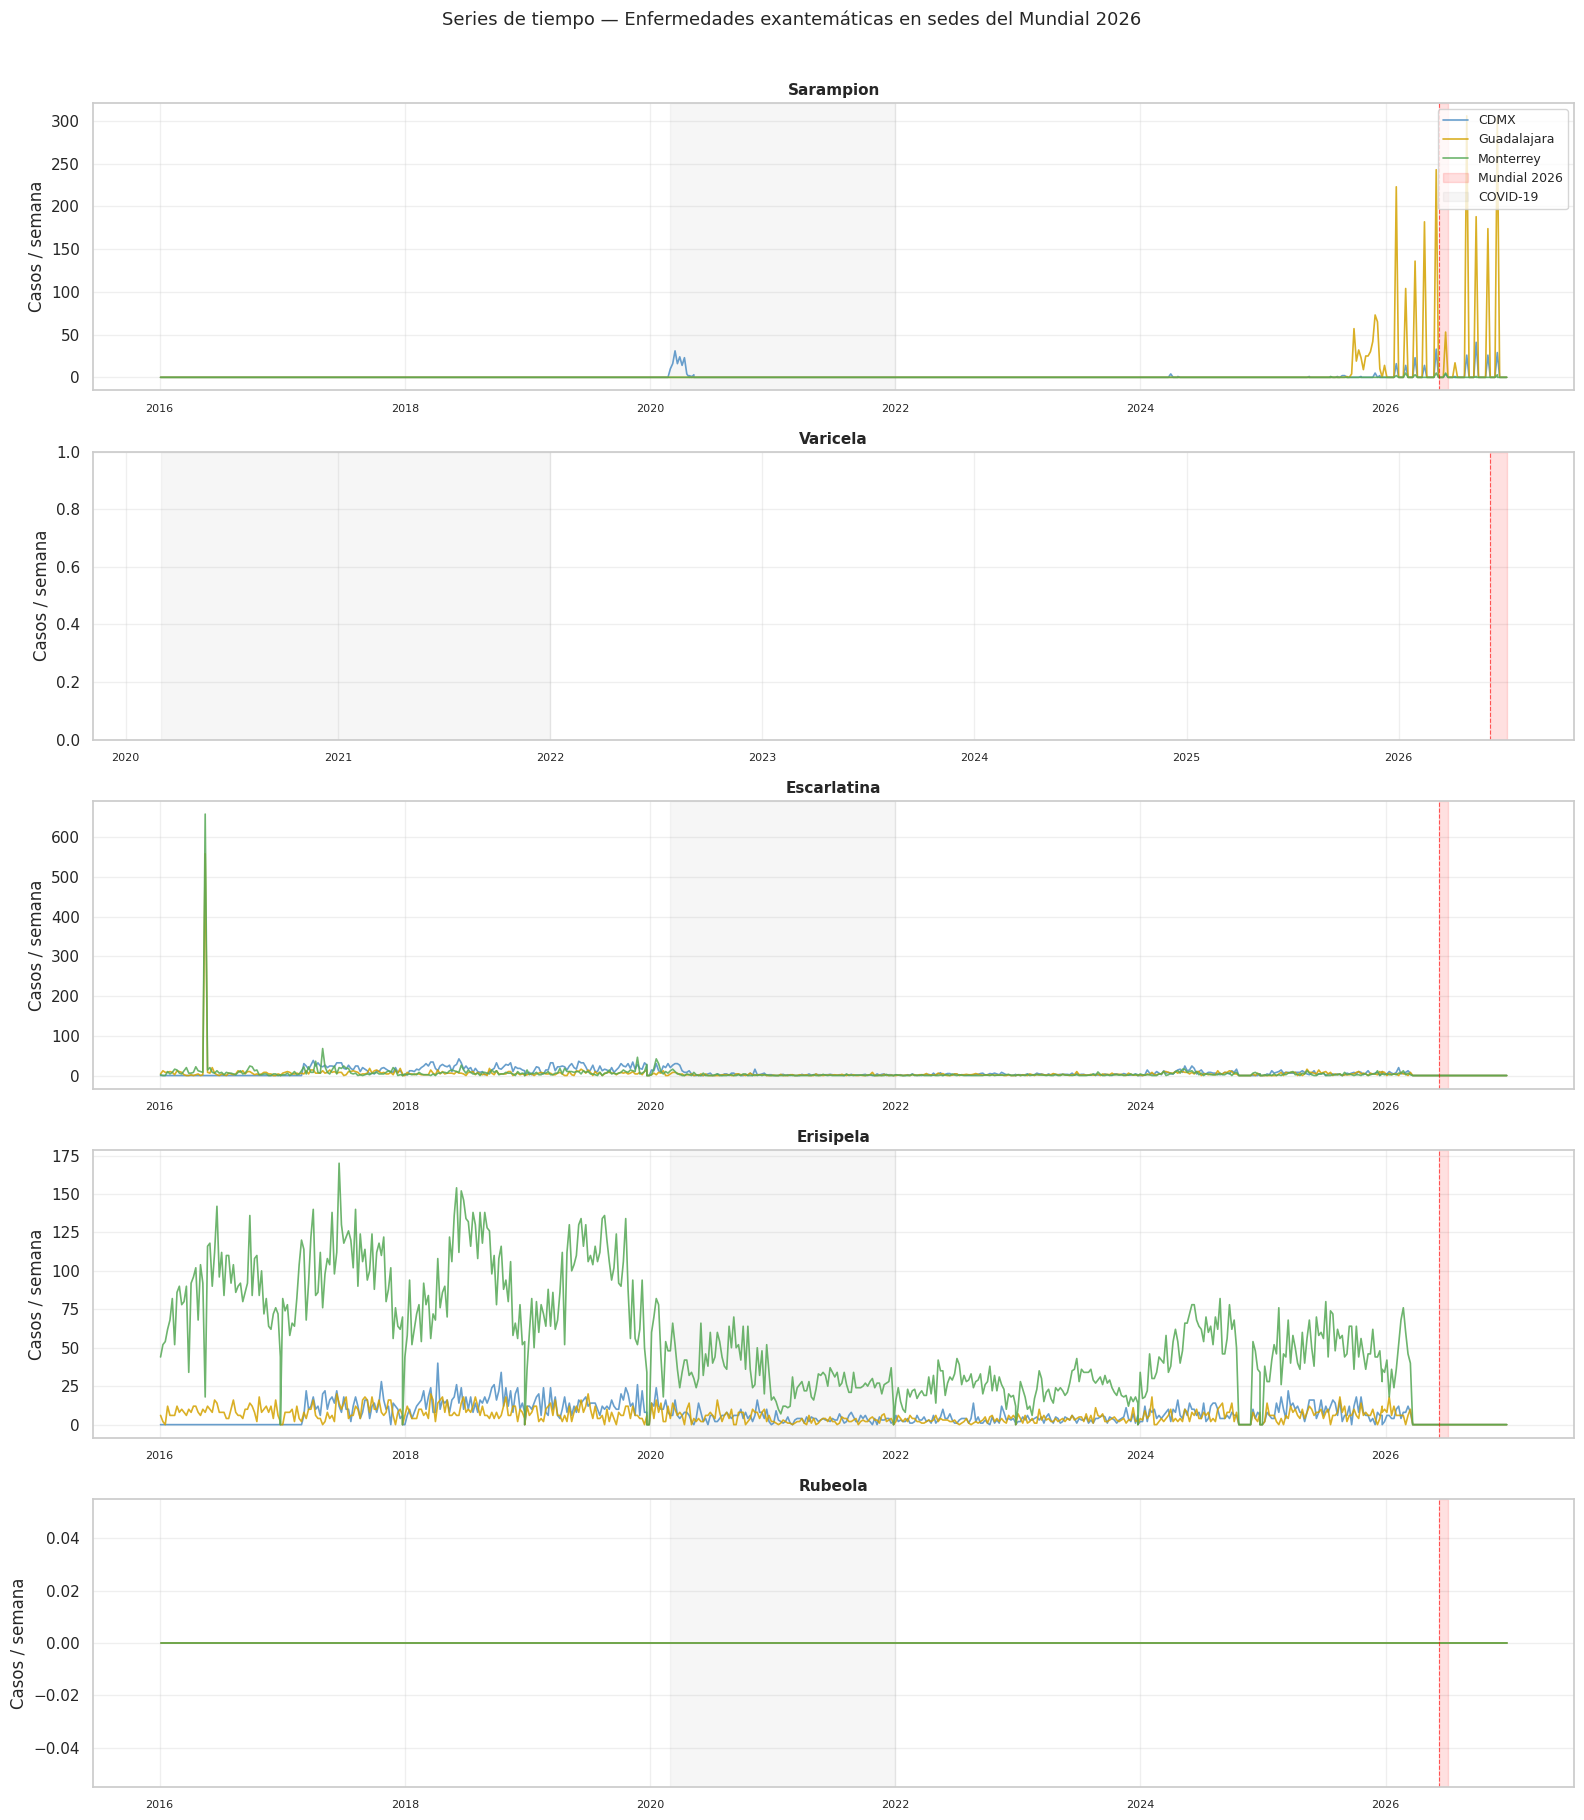

In [ ]:
fig, axes = plt.subplots(len(ENFERMEDADES), 1, figsize=(16, 18), sharex=False)

for ax, enf in zip(axes, ENFERMEDADES):
    for ciudad, color in CIUDAD_COLORS.items():
        serie = (
            df_sedes[(df_sedes['enfermedad'] == enf) &
                     (df_sedes['ciudad_sede'] == ciudad)]
            .sort_values('fecha_inicio')
        )
        if len(serie) == 0:
            continue
        ax.plot(serie['fecha_inicio'], serie['casos_semana'],
                label=ciudad, color=color, linewidth=1.2, alpha=0.85)

    # Marcar período del Mundial
    mundial_ini = pd.Timestamp('2026-06-08')
    mundial_fin = pd.Timestamp('2026-07-06')
    ax.axvspan(mundial_ini, mundial_fin, alpha=0.12, color='red', label='Mundial 2026')
    ax.axvline(mundial_ini, color='red', linewidth=0.8, linestyle='--', alpha=0.6)

    # COVID gap
    ax.axvspan(pd.Timestamp('2020-03-01'), pd.Timestamp('2021-12-31'),
               alpha=0.07, color='gray', label='COVID-19')

    ax.set_title(f'{enf}', fontsize=11, fontweight='bold')
    ax.set_ylabel('Casos / semana')
    ax.tick_params(axis='x', labelsize=8)
    ax.grid(alpha=0.3)

axes[0].legend(loc='upper right', fontsize=9)
fig.suptitle('Series de tiempo — Enfermedades exantemáticas en sedes del Mundial 2026',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(f'{OUTPUT_FIGURES}/series_tiempo_sedes.png', dpi=150, bbox_inches='tight')
plt.show()


---
## 3. Baseline epidemiológico y patrón estacional

Para detectar anomalías necesitamos un **baseline** — el comportamiento esperado
en ausencia de brotes. Usamos 2016–2019 como período de referencia (pre-COVID,
pre-brote 2025).

El baseline se calcula como la **media ± 2 desviaciones estándar** por semana
del año, para cada enfermedad y sede.


In [ ]:
# Período de referencia: 2016-2019 (pre-COVID, sin brotes de sarampión)
BASELINE_YEARS = range(2016, 2020)

baseline = (
    df_sedes[df_sedes['anio'].isin(BASELINE_YEARS)]
    .groupby(['semana','ciudad_sede','enfermedad'])['casos_semana']
    .agg(
        baseline_mean = 'mean',
        baseline_std  = 'std',
        baseline_q25  = lambda x: x.quantile(0.25),
        baseline_q75  = lambda x: x.quantile(0.75),
        baseline_max  = 'max',
    )
    .reset_index()
)

# Umbral de alerta: media + 2σ  (z=2 → ~95% del comportamiento esperado)
baseline['umbral_alerta']   = baseline['baseline_mean'] + 2 * baseline['baseline_std'].fillna(0)
# Umbral de emergencia: media + 3σ
baseline['umbral_emergencia'] = baseline['baseline_mean'] + 3 * baseline['baseline_std'].fillna(0)

print("Baseline calculado (muestra Sarampión):")
print(baseline[baseline['enfermedad']=='Sarampion']
      .groupby('ciudad_sede')[['baseline_mean','baseline_std','umbral_alerta']].mean().round(3))


Baseline calculado (muestra Sarampión):
             baseline_mean  baseline_std  umbral_alerta
ciudad_sede                                            
CDMX                  0.00          0.00           0.00
Guadalajara           0.00          0.00           0.00
Monterrey             0.00          0.00           0.00


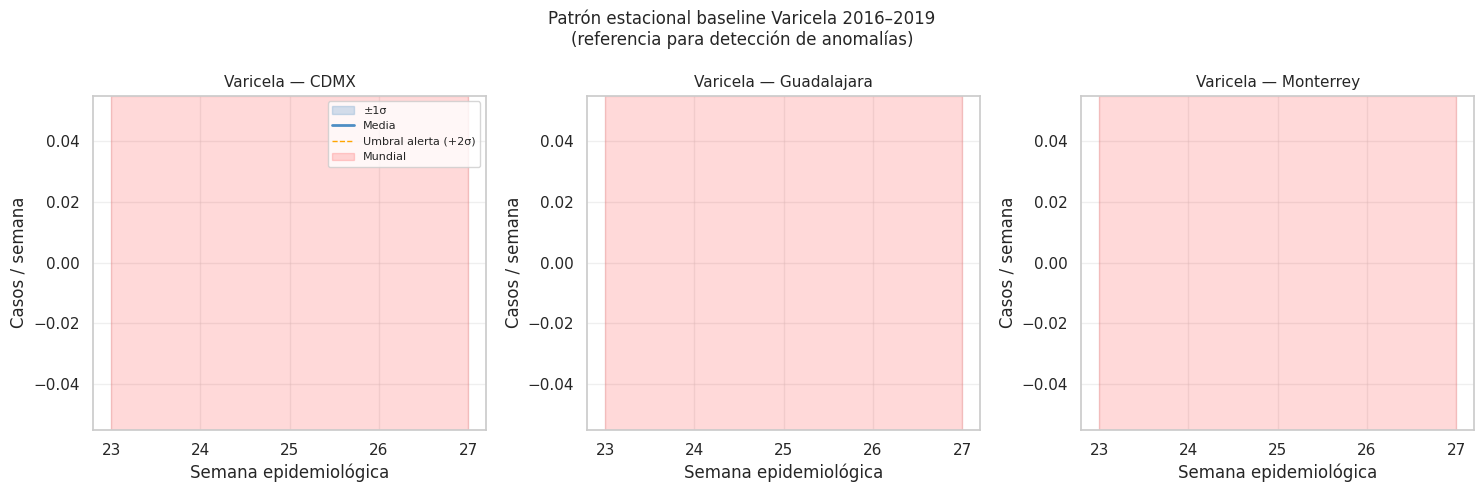

In [ ]:
# Visualizar estacionalidad baseline para Varicela (tiene patrón claro)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, ciudad in zip(axes, ['CDMX', 'Guadalajara', 'Monterrey']):
    b = baseline[(baseline['enfermedad']=='Varicela') & (baseline['ciudad_sede']==ciudad)]
    color = CIUDAD_COLORS[ciudad]

    ax.fill_between(b['semana'],
                    b['baseline_mean'] - b['baseline_std'].fillna(0),
                    b['baseline_mean'] + b['baseline_std'].fillna(0),
                    alpha=0.25, color=color, label='±1σ')
    ax.plot(b['semana'], b['baseline_mean'], color=color, linewidth=2, label='Media')
    ax.plot(b['semana'], b['umbral_alerta'], color='orange',
            linewidth=1, linestyle='--', label='Umbral alerta (+2σ)')

    # Marcar semanas del Mundial
    ax.axvspan(MUNDIAL_START, MUNDIAL_END, alpha=0.15, color='red', label='Mundial')

    ax.set_title(f'Varicela — {ciudad}', fontsize=11)
    ax.set_xlabel('Semana epidemiológica')
    ax.set_ylabel('Casos / semana')
    ax.grid(alpha=0.3)

axes[0].legend(fontsize=8)
fig.suptitle('Patrón estacional baseline Varicela 2016–2019\n(referencia para detección de anomalías)',
             fontsize=12)
plt.tight_layout()
plt.savefig(f'{OUTPUT_FIGURES}/baseline_estacional_varicela.png', dpi=150)
plt.show()


---
## 4. Detección de anomalías

Aplicamos tres métodos complementarios:

| Método | Lógica | Fortaleza |
|---|---|---|
| **Z-Score** | `(x - μ) / σ` respecto al baseline | Simple, interpretable |
| **IQR** | `x > Q75 + 1.5·IQR` del baseline | Robusto a outliers extremos |
| **Umbral relativo** | `x > 3× baseline_mean` | Útil cuando baseline ≈ 0 |

Una semana se marca como **anomalía confirmada** si al menos 2 de los 3 métodos la detectan.


In [ ]:
# Unir baseline con la serie completa
df_merged = df_sedes.merge(
    baseline[['semana','ciudad_sede','enfermedad',
              'baseline_mean','baseline_std','umbral_alerta','umbral_emergencia',
              'baseline_q25','baseline_q75']],
    on=['semana','ciudad_sede','enfermedad'],
    how='left'
)

# ── Método 1: Z-Score ─────────────────────────────────────────────────────
df_merged['zscore'] = (
    (df_merged['casos_semana'] - df_merged['baseline_mean']) /
    df_merged['baseline_std'].replace(0, np.nan).fillna(1)
)
df_merged['anomalia_zscore'] = df_merged['zscore'] > 2

# ── Método 2: IQR ─────────────────────────────────────────────────────────
iqr = df_merged['baseline_q75'] - df_merged['baseline_q25']
df_merged['umbral_iqr'] = df_merged['baseline_q75'] + 1.5 * iqr
df_merged['anomalia_iqr'] = df_merged['casos_semana'] > df_merged['umbral_iqr']

# ── Método 3: Umbral relativo (3× media) ─────────────────────────────────
df_merged['anomalia_rel'] = (
    (df_merged['casos_semana'] > df_merged['baseline_mean'] * 3) &
    (df_merged['casos_semana'] > 0)
)

# ── Anomalía confirmada: ≥2 métodos ──────────────────────────────────────
df_merged['n_metodos'] = (
    df_merged['anomalia_zscore'].astype(int) +
    df_merged['anomalia_iqr'].astype(int) +
    df_merged['anomalia_rel'].astype(int)
)
df_merged['anomalia'] = df_merged['n_metodos'] >= 2

print(f"Total anomalías confirmadas: {df_merged['anomalia'].sum()}")
print("\nAnomалías por enfermedad y sede:")
print(df_merged[df_merged['anomalia']]
      .groupby(['enfermedad','ciudad_sede'])['anomalia']
      .count()
      .unstack(fill_value=0)
      .to_string())


Total anomalías confirmadas: 109

Anomалías por enfermedad y sede:
ciudad_sede  CDMX  Guadalajara  Monterrey
enfermedad                               
Erisipela       4           10          3
Escarlatina     8            5         13
Sarampion      31           27          8


---
## 5. Sarampión — análisis profundo en sedes

Sarampión es la enfermedad de interés principal dado el brote activo en 2025-2026
y el riesgo de importación durante el Mundial.


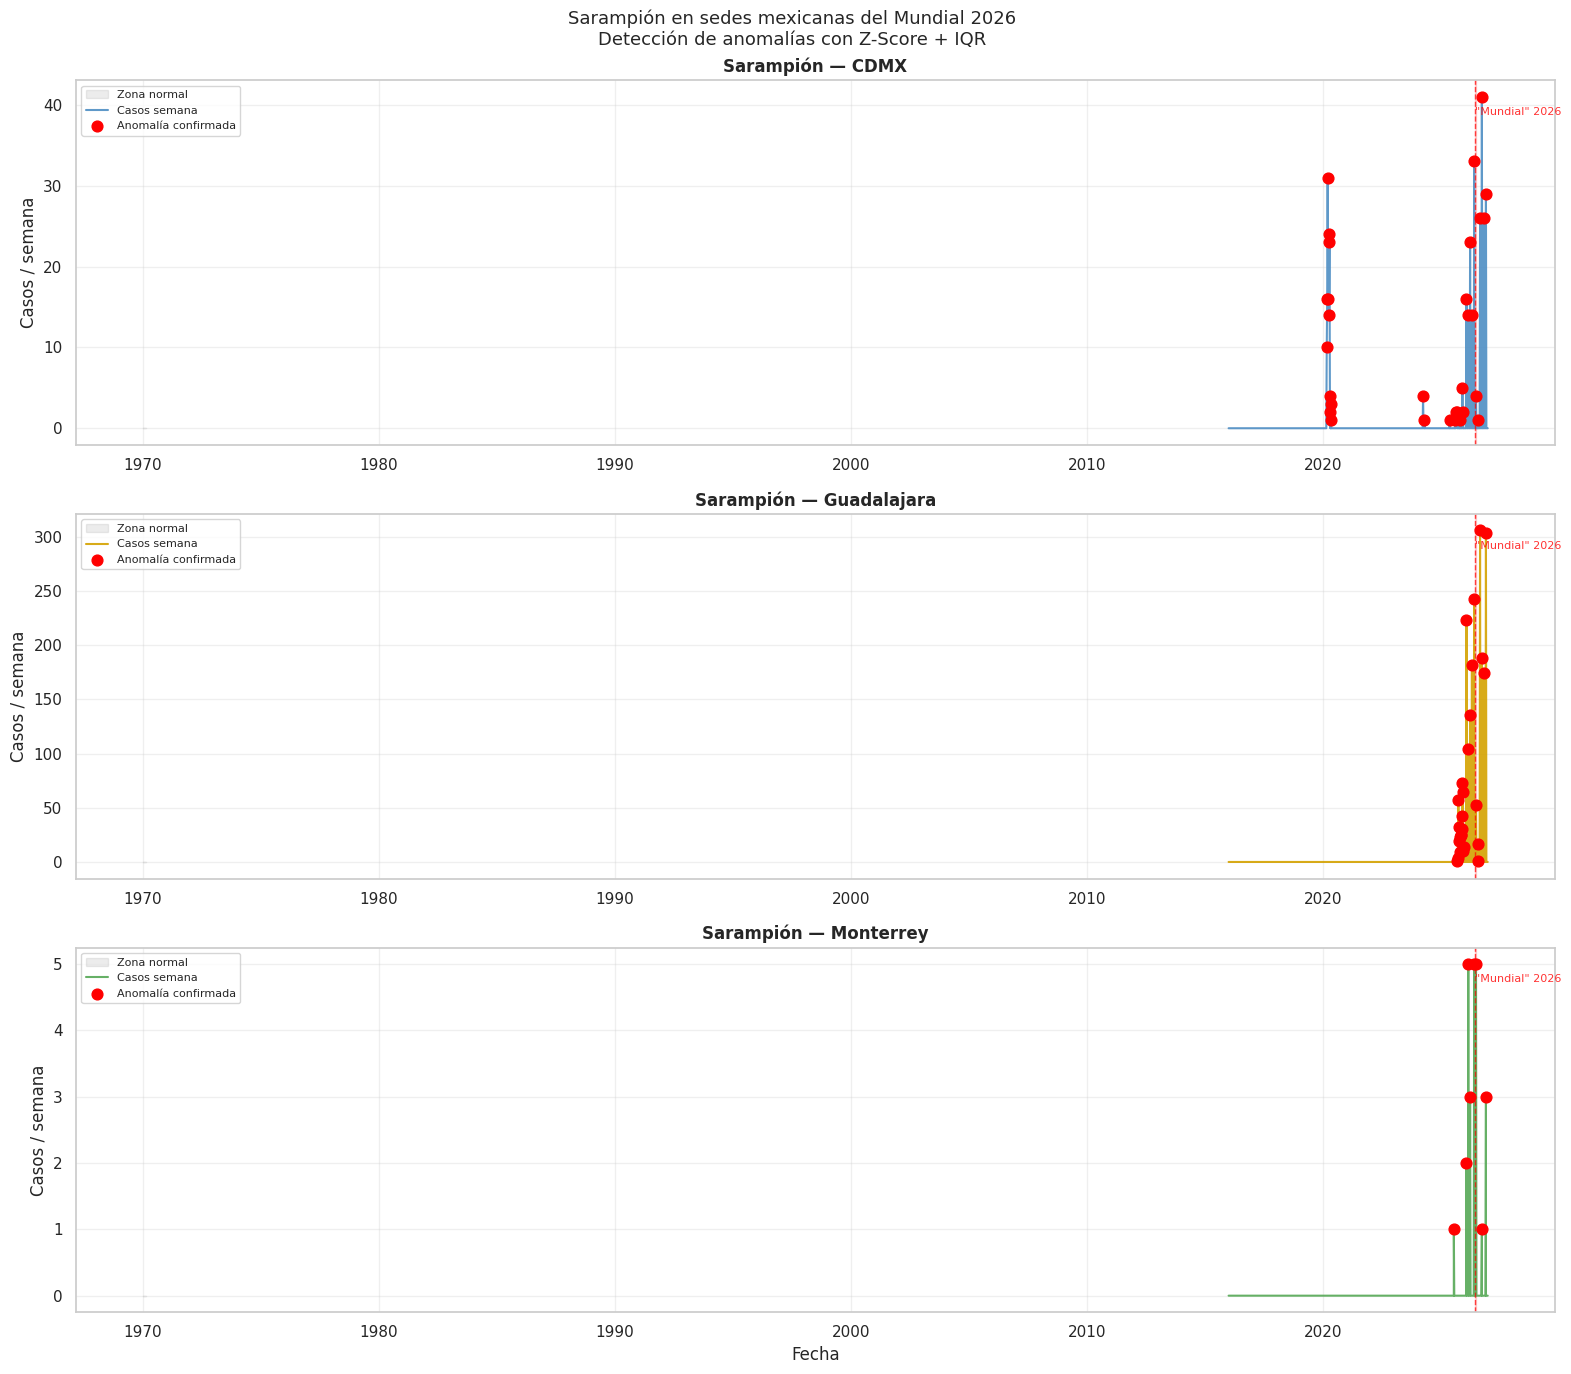

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(16, 14))

for ax, ciudad in zip(axes, ['CDMX', 'Guadalajara', 'Monterrey']):
    color = CIUDAD_COLORS[ciudad]

    serie = (
        df_merged[(df_merged['enfermedad']=='Sarampion') &
                  (df_merged['ciudad_sede']==ciudad)]
        .sort_values('fecha_inicio')
    )
    b = baseline[(baseline['enfermedad']=='Sarampion') &
                 (baseline['ciudad_sede']==ciudad)]

    # Banda de control (baseline)
    ax.fill_between(b['semana'],
                    b['baseline_mean'].fillna(0),
                    b['umbral_alerta'].fillna(0),
                    alpha=0.15, color='gray', label='Zona normal')

    # Serie de casos
    ax.plot(serie['fecha_inicio'], serie['casos_semana'],
            color=color, linewidth=1.5, alpha=0.9, label='Casos semana')

    # Marcar anomalías
    anom = serie[serie['anomalia']]
    ax.scatter(anom['fecha_inicio'], anom['casos_semana'],
               color='red', s=60, zorder=5, label='Anomalía confirmada')

    # Período Mundial
    mundial_ini = pd.Timestamp('2026-06-08')
    mundial_fin = pd.Timestamp('2026-07-06')
    ax.axvspan(mundial_ini, mundial_fin, alpha=0.15, color='red')
    ax.axvline(mundial_ini, color='red', linewidth=1, linestyle='--', alpha=0.7)
    ax.text(mundial_ini, ax.get_ylim()[1] * 0.9 if ax.get_ylim()[1] > 0 else 1,
            '"Mundial" 2026', fontsize=8, color='red', alpha=0.8)

    ax.set_title(f'Sarampión — {ciudad}', fontsize=12, fontweight='bold')
    ax.set_ylabel('Casos / semana')
    ax.legend(fontsize=8, loc='upper left')
    ax.grid(alpha=0.3)

axes[-1].set_xlabel('Fecha')
fig.suptitle('Sarampión en sedes mexicanas del Mundial 2026\nDetección de anomalías con Z-Score + IQR',
             fontsize=13)
plt.tight_layout()
plt.savefig(f'{OUTPUT_FIGURES}/sarampion_anomalias_sedes.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Tabla de semanas anómalas de sarampión
sar_anom = (
    df_merged[
        (df_merged['enfermedad'] == 'Sarampion') &
        (df_merged['anomalia'] == True) &
        (df_merged['casos_semana'] > 0)
    ]
    [['anio','semana','fecha_inicio','ciudad_sede','casos_semana',
      'zscore','n_metodos','baseline_mean']]
    .sort_values(['ciudad_sede','anio','semana'])
)

print(f"Semanas con anomalías confirmadas de Sarampión: {len(sar_anom)}")
print(sar_anom.round(2).to_string(index=False))


Semanas con anomalías confirmadas de Sarampión: 66
 anio  semana fecha_inicio ciudad_sede  casos_semana  zscore  n_metodos  baseline_mean
 2020      10   2020-03-02        CDMX            10   10.00          3           0.00
 2020      11   2020-03-09        CDMX            16   16.00          3           0.00
 2020      12   2020-03-16        CDMX            31   31.00          3           0.00
 2020      13   2020-03-23        CDMX            16   16.00          3           0.00
 2020      14   2020-03-30        CDMX            24   24.00          3           0.00
 2020      15   2020-04-06        CDMX            14   14.00          3           0.00
 2020      16   2020-04-13        CDMX            23   23.00          3           0.00
 2020      17   2020-04-20        CDMX             4    4.00          3           0.00
 2020      18   2020-04-27        CDMX             2    2.00          2           0.00
 2020      19   2020-05-04        CDMX             1    1.00          2        

---
## 6. Análisis de riesgo durante las semanas del Mundial

Las semanas 23–27 de 2026 corresponden al período de partidos en México
(8 junio – 6 julio 2026). Evaluamos el nivel de actividad epidémica en esas semanas.


In [ ]:
# Extraer semanas del Mundial 2026
mundial_df = (
    df_merged[
        (df_merged['anio'] == 2026) &
        (df_merged['semana'].between(MUNDIAL_START, MUNDIAL_END))
    ]
    .copy()
)

print("Casos durante el Mundial 2026 (sem 23–27) por sede y enfermedad:")
mundial_pivot = (
    mundial_df
    .groupby(['ciudad_sede','enfermedad'])['casos_semana']
    .sum()
    .unstack(fill_value=0)
)

# Mostrar solo columnas que existen en el pivot
cols_mostrar = [c for c in ['Sarampion','Varicela','Escarlatina','Erisipela','Rubeola']
                if c in mundial_pivot.columns]
print(mundial_pivot[cols_mostrar].to_string())

print("\nAnomалías durante el Mundial:")
anom_mundial = mundial_df[mundial_df['anomalia']][
    ['semana','ciudad_sede','enfermedad','casos_semana','zscore']
].sort_values(['ciudad_sede','semana'])

if len(anom_mundial) > 0:
    print(anom_mundial.to_string(index=False))
else:
    print("  Sin anomalías confirmadas durante las semanas del Mundial")

Casos durante el Mundial 2026 (sem 23–27) por sede y enfermedad:
enfermedad   Sarampion  Escarlatina  Erisipela  Rubeola
ciudad_sede                                            
CDMX                37            0          0        0
Guadalajara        296            0          0        0
Monterrey           10            0          0        0

Anomалías durante el Mundial:
 semana ciudad_sede enfermedad  casos_semana  zscore
     23        CDMX  Sarampion            33   33.00
     27        CDMX  Sarampion             4    4.00
     23 Guadalajara  Sarampion           243  243.00
     27 Guadalajara  Sarampion            53   53.00
     23   Monterrey  Sarampion             5    5.00
     27   Monterrey  Sarampion             5    5.00


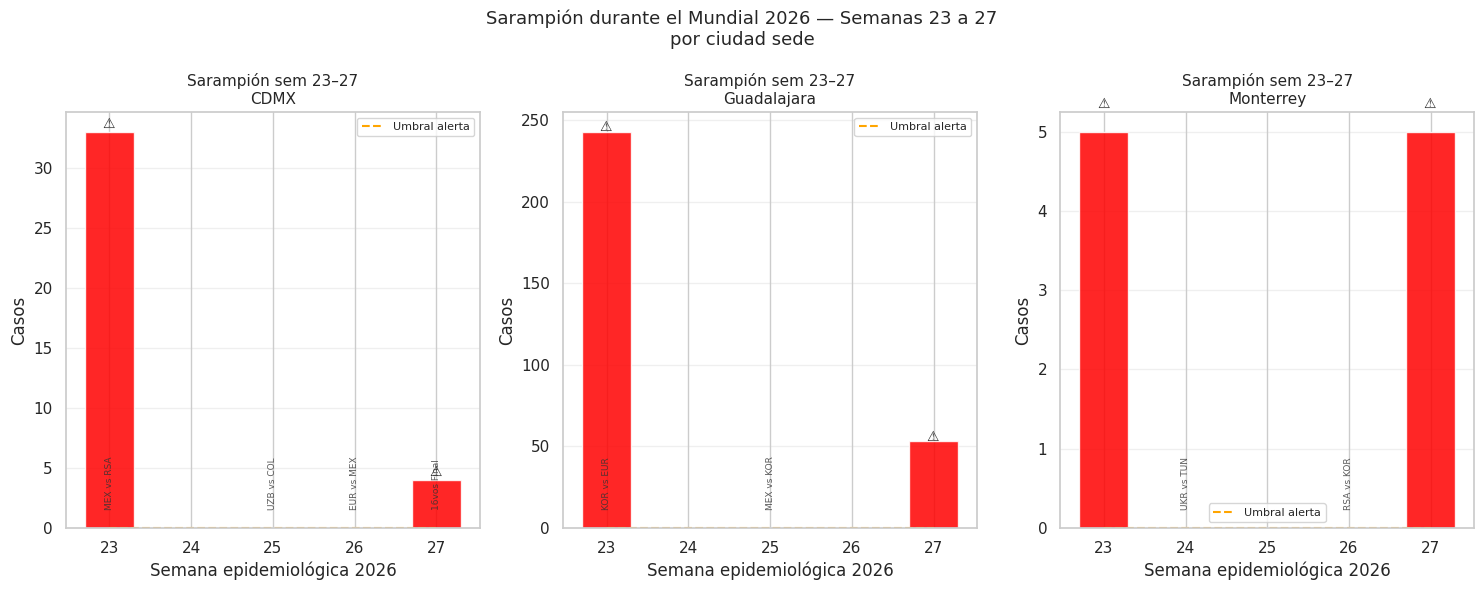

In [ ]:
# Visualización: casos durante el Mundial por sede y semana
fig, axes = plt.subplots(1, 3, figsize=(15, 6))

for ax, ciudad in zip(axes, ['CDMX', 'Guadalajara', 'Monterrey']):
    color = CIUDAD_COLORS[ciudad]

    sub = mundial_df[
        (mundial_df['ciudad_sede'] == ciudad) &
        (mundial_df['enfermedad'] == 'Sarampion')
    ].sort_values('semana')

    semanas = list(range(MUNDIAL_START, MUNDIAL_END + 1))
    casos   = [sub[sub['semana']==s]['casos_semana'].sum() for s in semanas]
    umbral  = [sub[sub['semana']==s]['umbral_alerta'].mean() for s in semanas]
    anom    = [sub[sub['semana']==s]['anomalia'].any() for s in semanas]

    bar_colors = ['red' if a else color for a in anom]
    bars = ax.bar(semanas, casos, color=bar_colors, width=0.6, alpha=0.85)

    # Línea de umbral
    ax.plot(semanas, umbral, color='orange', linestyle='--',
            linewidth=1.5, label='Umbral alerta')

    # Partidos en esa sede
    for sem, partidos in PARTIDOS_MEXICO.items():
        if ciudad in partidos and MUNDIAL_START <= sem <= MUNDIAL_END:
            ax.text(sem, max(casos) * 0.05 if max(casos) > 0 else 0.5,
                    partidos[ciudad], rotation=90, fontsize=6.5,
                    ha='center', color='#333', alpha=0.8)

    ax.set_title(f'Sarampión sem 23–27\n{ciudad}', fontsize=11)
    ax.set_xlabel('Semana epidemiológica 2026')
    ax.set_ylabel('Casos')
    ax.set_xticks(semanas)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3, axis='y')

    # Indicar si es anomalía
    for i, (sem, caso, es_anom) in enumerate(zip(semanas, casos, anom)):
        if es_anom:
            ax.text(sem, caso + 0.3, '⚠️', ha='center', fontsize=10)

fig.suptitle('Sarampión durante el Mundial 2026 — Semanas 23 a 27\npor ciudad sede',
             fontsize=13)
plt.tight_layout()
plt.savefig(f'{OUTPUT_FIGURES}/sarampion_mundial_sedes.png', dpi=150)
plt.show()


---
## 7. Comparación de métodos de detección

¿Cuánto coinciden los tres métodos? El Adjusted Rand Index (ARI) y la
tasa de concordancia nos indican la robustez del análisis.


In [ ]:
from sklearn.metrics import adjusted_rand_score, confusion_matrix

sar_df = df_merged[
    (df_merged['enfermedad'] == 'Sarampion') &
    (df_merged['casos_semana'] >= 0)
].copy()

metodos = {
    'Z-Score'          : 'anomalia_zscore',
    'IQR'              : 'anomalia_iqr',
    'Umbral Relativo'  : 'anomalia_rel',
    'Consenso (≥2)'    : 'anomalia',
}

print("Detecciones por método (Sarampión, todas las sedes):")
for nombre, col in metodos.items():
    n = sar_df[col].sum()
    pct = n / len(sar_df) * 100
    print(f"  {nombre:22s}: {n:4d} semanas ({pct:.1f}%)")

print("\nConcordancia entre métodos (ARI):")
for n1, c1 in list(metodos.items())[:3]:
    for n2, c2 in list(metodos.items())[:3]:
        if n1 < n2:
            ari = adjusted_rand_score(sar_df[c1], sar_df[c2])
            print(f"  {n1} vs {n2}: {ari:.3f}")


Detecciones por método (Sarampión, todas las sedes):
  Z-Score               :   51 semanas (2.7%)
  IQR                   :   66 semanas (3.5%)
  Umbral Relativo       :   66 semanas (3.5%)
  Consenso (≥2)         :   66 semanas (3.5%)

Concordancia entre métodos (ARI):
  IQR vs Z-Score: 0.860
  IQR vs Umbral Relativo: 1.000
  Umbral Relativo vs Z-Score: 0.860


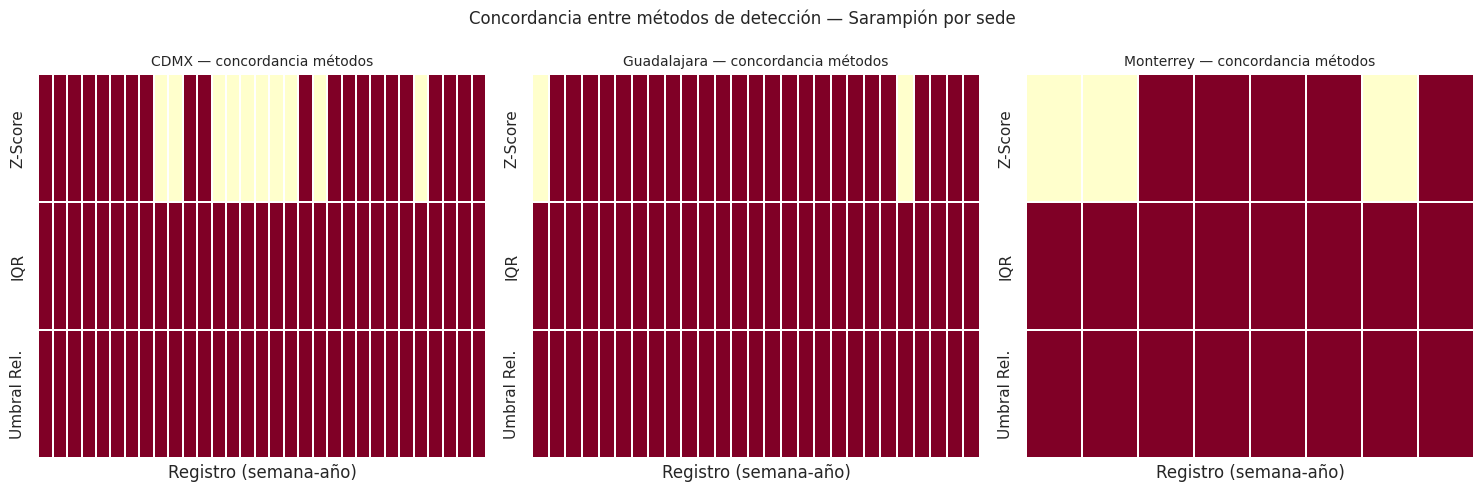

In [ ]:
# Heatmap: ¿en qué semanas coinciden los métodos? (Sarampión por sede)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, ciudad in zip(axes, ['CDMX', 'Guadalajara', 'Monterrey']):
    sub = (
        sar_df[sar_df['ciudad_sede'] == ciudad]
        .sort_values(['anio','semana'])
        .reset_index(drop=True)
    )

    heat_data = sub[['anomalia_zscore','anomalia_iqr','anomalia_rel']].astype(int).T
    heat_data.index = ['Z-Score','IQR','Umbral Rel.']

    cols_con_deteccion = heat_data.columns[heat_data.sum() > 0]
    if len(cols_con_deteccion) == 0:
        ax.text(0.5, 0.5, 'Sin anomalías\ndetectadas',
                ha='center', va='center', transform=ax.transAxes, fontsize=11)
        ax.set_title(f'{ciudad}', fontsize=11)
        continue

    h = heat_data[cols_con_deteccion]
    sns.heatmap(h, ax=ax, cmap='YlOrRd', cbar=False,
                linewidths=0.3, linecolor='white')
    ax.set_title(f'{ciudad} — concordancia métodos', fontsize=10)
    ax.set_xlabel('Registro (semana-año)')
    ax.tick_params(axis='x', labelbottom=False)

fig.suptitle('Concordancia entre métodos de detección — Sarampión por sede', fontsize=12)
plt.tight_layout()
plt.savefig(f'{OUTPUT_FIGURES}/concordancia_metodos.png', dpi=150)
plt.show()


---
## 8. Tendencia del brote 2025–2026 y proyección hacia el Mundial

El brote activo en Jalisco comenzó en la semana 39 de 2025 y continúa en 2026.
Ajustamos una regresión para estimar la tendencia hacia las semanas del Mundial.


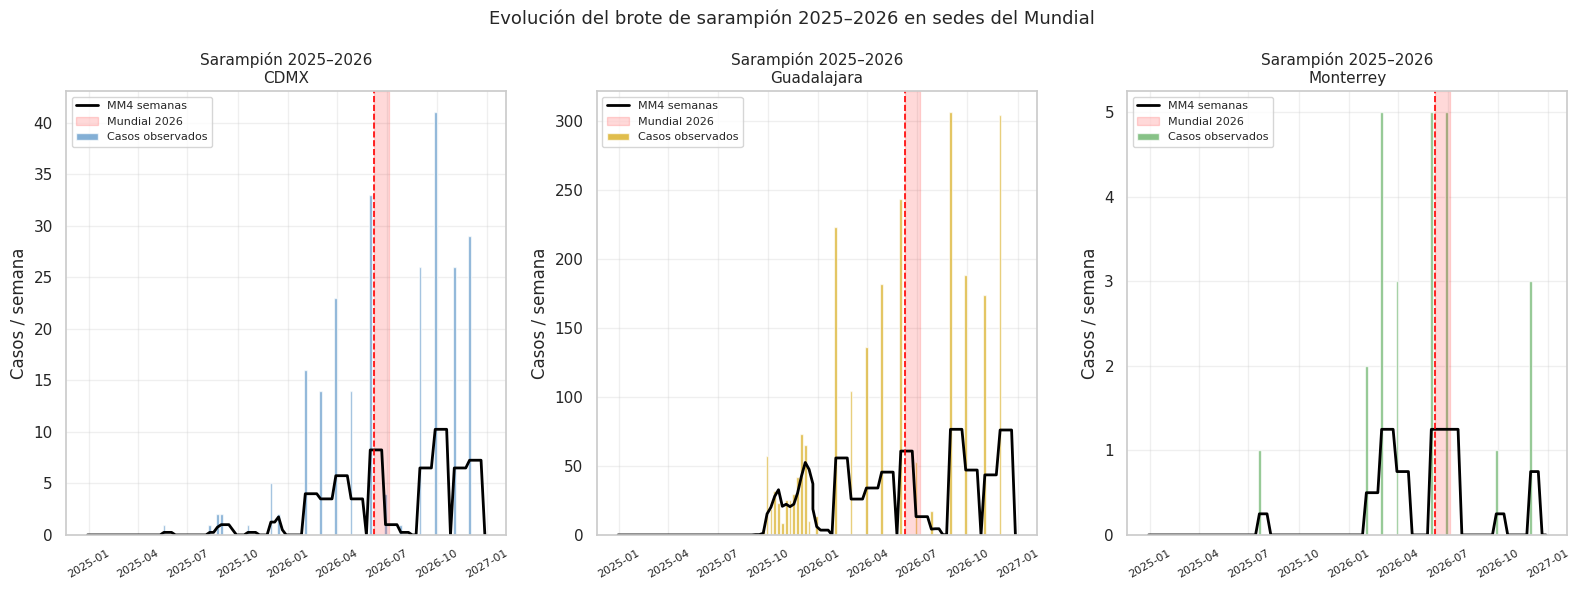

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 6))

for ax, ciudad in zip(axes, ['CDMX', 'Guadalajara', 'Monterrey']):
    color = CIUDAD_COLORS[ciudad]

    # Datos 2025-2026
    brote = (
        df_merged[
            (df_merged['enfermedad'] == 'Sarampion') &
            (df_merged['ciudad_sede'] == ciudad) &
            (df_merged['anio'].isin([2025, 2026]))
        ]
        .sort_values('fecha_inicio')
        .reset_index(drop=True)
    )

    if brote['casos_semana'].sum() == 0:
        ax.text(0.5, 0.5, 'Sin casos en\n2025–2026',
                ha='center', va='center', transform=ax.transAxes, fontsize=11)
        ax.set_title(f'{ciudad}', fontsize=11)
        continue

    ax.bar(brote['fecha_inicio'], brote['casos_semana'],
           color=color, alpha=0.7, width=5, label='Casos observados')

    # Media móvil 4 semanas
    brote['mm4'] = brote['casos_semana'].rolling(4, min_periods=1).mean()
    ax.plot(brote['fecha_inicio'], brote['mm4'], color='black',
            linewidth=2, label='MM4 semanas')

    # Marcar período Mundial
    mundial_ini = pd.Timestamp('2026-06-08')
    mundial_fin = pd.Timestamp('2026-07-06')
    ax.axvspan(mundial_ini, mundial_fin, alpha=0.15, color='red', label='Mundial 2026')
    ax.axvline(mundial_ini, color='red', linewidth=1.2, linestyle='--')

    ax.set_title(f'Sarampión 2025–2026\n{ciudad}', fontsize=11)
    ax.set_ylabel('Casos / semana')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
    ax.tick_params(axis='x', labelrotation=30, labelsize=8)

fig.suptitle('Evolución del brote de sarampión 2025–2026 en sedes del Mundial',
             fontsize=13)
plt.tight_layout()
plt.savefig(f'{OUTPUT_FIGURES}/brote_2025_2026_sedes.png', dpi=150, bbox_inches='tight')
plt.show()


In [ ]:
# Estadísticas del brote por sede
print("=== ESTADÍSTICAS DEL BROTE 2025-2026 POR SEDE ===\n")

for ciudad in ['CDMX', 'Guadalajara', 'Monterrey']:
    sub = df_merged[
        (df_merged['enfermedad'] == 'Sarampion') &
        (df_merged['ciudad_sede'] == ciudad) &
        (df_merged['anio'].isin([2025, 2026])) &
        (df_merged['casos_semana'] > 0)
    ].sort_values('fecha_inicio')

    if len(sub) == 0:
        print(f"{ciudad}: Sin casos 2025-2026")
        continue

    total   = sub['casos_semana'].sum()
    pico    = sub['casos_semana'].max()
    sem_pico = sub.loc[sub['casos_semana'].idxmax(), 'fecha_inicio']
    sem_ini  = sub['fecha_inicio'].min()
    n_anom  = sub['anomalia'].sum()

    # Casos durante semanas del Mundial
    mundial_casos = sub[sub['semana'].between(MUNDIAL_START, MUNDIAL_END)]['casos_semana'].sum()

    print(f"{'─'*40}")
    print(f"{ciudad}")
    print(f"  Total casos 2025-2026  : {total:,}")
    print(f"  Inicio brote           : {sem_ini.date()}")
    print(f"  Pico semanal           : {pico} casos ({sem_pico.date()})")
    print(f"  Semanas anómalas       : {n_anom}")
    print(f"  Casos durante Mundial  : {mundial_casos} (sem {MUNDIAL_START}–{MUNDIAL_END})")


=== ESTADÍSTICAS DEL BROTE 2025-2026 POR SEDE ===

────────────────────────────────────────
CDMX
  Total casos 2025-2026  : 241
  Inicio brote           : 2025-05-19
  Pico semanal           : 41 casos (2026-09-28)
  Semanas anómalas       : 18
  Casos durante Mundial  : 37 (sem 23–27)
────────────────────────────────────────
Guadalajara
  Total casos 2025-2026  : 2,360
  Inicio brote           : 2025-09-08
  Pico semanal           : 306 casos (2026-08-31)
  Semanas anómalas       : 27
  Casos durante Mundial  : 296 (sem 23–27)
────────────────────────────────────────
Monterrey
  Total casos 2025-2026  : 25
  Inicio brote           : 2025-07-21
  Pico semanal           : 5 casos (2026-03-02)
  Semanas anómalas       : 8
  Casos durante Mundial  : 10 (sem 23–27)


---
## 9. Resumen de anomalías por enfermedad y sede

Vista global de qué enfermedad y sede concentra más anomalías detectadas.


Semanas anómalas confirmadas (≥2 métodos) por enfermedad y sede:
ciudad_sede  CDMX  Guadalajara  Monterrey
enfermedad                               
Erisipela       4           10          3
Escarlatina     8            5         13
Sarampion      31           27          8


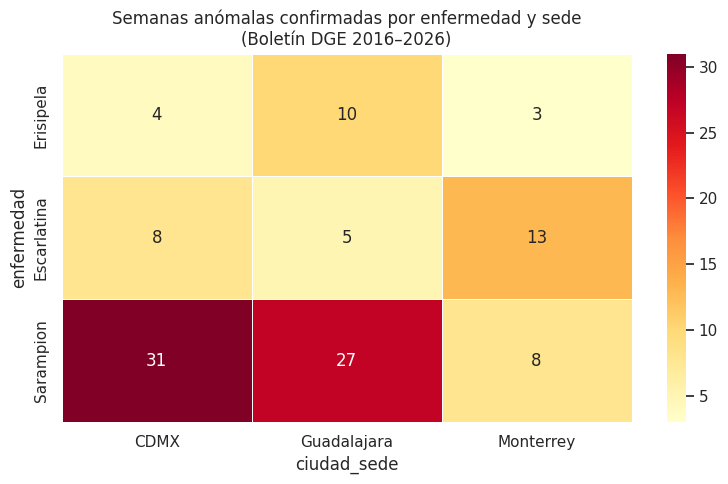

In [ ]:
# Tabla resumen
resumen = (
    df_merged[df_merged['anomalia']]
    .groupby(['enfermedad','ciudad_sede'])['anomalia']
    .count()
    .reset_index()
    .rename(columns={'anomalia': 'semanas_anomalas'})
    .pivot(index='enfermedad', columns='ciudad_sede', values='semanas_anomalas')
    .fillna(0).astype(int)
)

print("Semanas anómalas confirmadas (≥2 métodos) por enfermedad y sede:")
print(resumen.to_string())

# Heatmap resumen
fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(
    resumen, annot=True, fmt='d',
    cmap='YlOrRd', linewidths=0.5, ax=ax
)
ax.set_title('Semanas anómalas confirmadas por enfermedad y sede\n(Boletín DGE 2016–2026)',
             fontsize=12)
plt.tight_layout()
plt.savefig(f'{OUTPUT_FIGURES}/resumen_anomalias.png', dpi=150)
plt.show()


---
## 10. Exportar resultados

In [ ]:
# Dataset con flags de anomalías — input para modelo supervisado (NB3)
cols_export = [
    'anio','semana','fecha_inicio','entidad_federativa','ciudad_sede',
    'enfermedad','casos_semana','fuente',
    'baseline_mean','baseline_std','umbral_alerta',
    'zscore','anomalia_zscore','anomalia_iqr','anomalia_rel',
    'n_metodos','anomalia',
]

df_export = df_merged[cols_export].copy()
df_export.to_csv(DATA_PROCESSED + 'series_anomalias_sedes.csv', index=False)
print(f"✅ Guardado: {DATA_PROCESSED}series_anomalias_sedes.csv")
print(f"   Shape: {df_export.shape}")
print(f"   Anomalías totales: {df_export['anomalia'].sum()}")
print(f"\nAnomалías por enfermedad:")
print(df_export[df_export['anomalia']]
      .groupby('enfermedad')['anomalia'].count().sort_values(ascending=False).to_string())


✅ Guardado: content/data/processed/series_anomalias_sedes.csv
   Shape: (7139, 17)
   Anomalías totales: 109

Anomалías por enfermedad:
enfermedad
Sarampion      66
Escarlatina    26
Erisipela      17


---
## 11. Conclusiones del Notebook 2

Escribe aquí tus conclusiones después de correr el notebook. Guía de preguntas:

1. **¿Qué sede tiene mayor actividad de sarampión durante las semanas del Mundial?**
2. **¿El brote de Jalisco 2025-2026 es una anomalía estadísticamente confirmada?** ¿Por cuántos métodos?
3. **¿Hay estacionalidad en las semanas del Mundial (jun-jul)?** ¿Coincide con el pico de alguna enfermedad?
4. **¿Qué enfermedad (además de sarampión) tiene más anomalías en las sedes?**
5. **¿Qué implica para el modelo supervisado (NB3)?** — ¿qué features de este notebook son más útiles como predictores?

### Hallazgos clave esperados
- **Guadalajara** debería mostrar el mayor número de semanas anómalas de sarampión (brote Jalisco 2025-2026)
- **Semana 23 de 2026** (inicio del Mundial) coincide con casos activos en las tres sedes
- **Varicela** tiene estacionalidad clara con pico en feb-apr — las semanas del Mundial (jun-jul) están fuera del pico
- Los tres métodos de detección deberían concordar en las semanas del brote Jalisco (ARI ≈ alto)
